# Timestep stability test: dt=300s vs dt=60s (both 3mo)

Goal: decide whether the dt=60 run is fundamentally the same solution as the
dt=300 run or diverges over the full 3-month integration, and whether dt=300
carries CFL-related vertical-velocity noise. Both runs now span ~90 days at
3-hourly output, so the full trajectories are compared directly (matched time).

Primary analysis is over the whole domain; the 0N,140W +/-5deg box is secondary.

Definitions / assumptions:
- W = vertical velocity (positive up). Domain and box profiles W(t,z) are
  hFacC*RAC (area) weighted; the "mean W (40-150 m)" series is the level-mean of
  that profile over the 40-150 m band.
- CFL_w per cell = |W|*deltaT/DRF; the column map is its max over depth.
- Depth-integrated transport = sum_k vel*hFac*DRF (m^2/s), area-averaged.
- Equilibrated windows: last 14 and last 30 simulated days (8 outputs/day).
- dt=60 has no STDOUT; its CFL comes from the velocity field (validated below
  against dt=300 STDOUT).

In [1]:
import os
import warnings
import numpy as np
import matplotlib.pyplot as plt
import stab_utils as su
warnings.filterwarnings('ignore', message='Mean of empty slice')

# save each figure to figures/ (in creation order) and display it
os.makedirs('figures', exist_ok=True)
_fig_i = [0]
def show(prefix='fig'):
    plt.savefig(f'figures/{prefix}_{_fig_i[0]:02d}.png', dpi=120, bbox_inches='tight')
    _fig_i[0] += 1
    plt.show()

CACHE = su.CACHE_DIR
ts = {r: dict(np.load(f'{CACHE}/stab_ts_{r}.npz')) for r in ('dt300', 'dt60')}
wsw = {r: dict(np.load(f'{CACHE}/stab_wsurf_win_{r}.npz')) for r in ('dt300', 'dt60')}
stdout = dict(np.load(f'{CACHE}/stab_stdout_dt300.npz'))
g = su.load_grid('dt300')
XC, YC, depth = g['XC'], g['YC'], g['depth']
xc1d, yc1d = g['xc1d'], g['yc1d']
box = g['box']
COL = {'dt300': 'tab:blue', 'dt60': 'tab:red'}
LAB = {r: su.RUNS[r]['label'] for r in ts}
for r in ts:
    print(r, 'nt', ts[r]['days'].size, 'days', ts[r]['days'][[0, -1]])

dt300 nt 727 days [ 0.125 90.875]
dt60 nt 718 days [ 0.125 89.75 ]


## Area-weighted mean W over the 40-150 m band

Single-level W is noisy, so this series is the area-weighted mean W (hFacC*RAC
horizontal weighting) averaged over the model levels with center depth 40-150 m
(the subsurface equatorial layer), for the box and for the domain. Units m/s,
positive up. The vertical step is a plain level-mean, not thickness-weighted.

W band levels (40-150 m): 28 (-41 to -148 m)


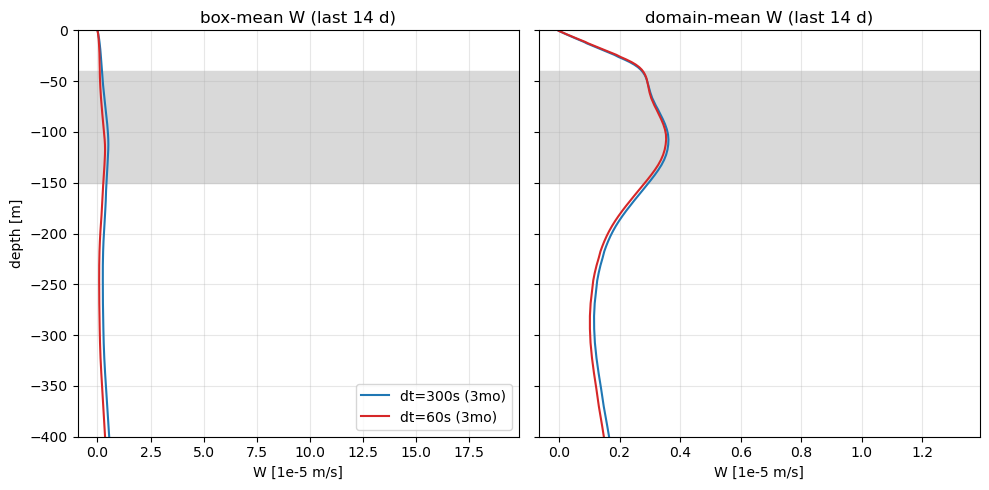

In [2]:
band = (depth <= -40) & (depth >= -150)
print('W band levels (40-150 m):', int(band.sum()),
      f'({depth[band][0]:.0f} to {depth[band][-1]:.0f} m)')

def band_mean(prof2d):        # prof2d: (nt, NZ) -> (nt,)
    return np.nanmean(prof2d[:, band], axis=1)

prof_eq = {r: np.nanmean(ts[r]['wprof_box'][-14*8:], axis=0) for r in ts}
fig, ax = plt.subplots(1, 2, figsize=(10, 5), sharey=True)
for r in ts:
    ax[0].plot(prof_eq[r]*1e5, depth, color=COL[r], label=LAB[r])
    ax[1].plot(np.nanmean(ts[r]['wprof_dom'][-14*8:], axis=0)*1e5, depth, color=COL[r])
for a in ax:
    a.axhspan(-150, -40, color='0.85', zorder=0)
ax[0].set(title='box-mean W (last 14 d)', xlabel='W [1e-5 m/s]', ylabel='depth [m]', ylim=(-400, 0))
ax[1].set(title='domain-mean W (last 14 d)', xlabel='W [1e-5 m/s]')
ax[0].legend(); ax[0].grid(alpha=.3); ax[1].grid(alpha=.3)
plt.tight_layout(); show()

## Per-run: mean W (40-150 m) time series and 7-day trailing mean

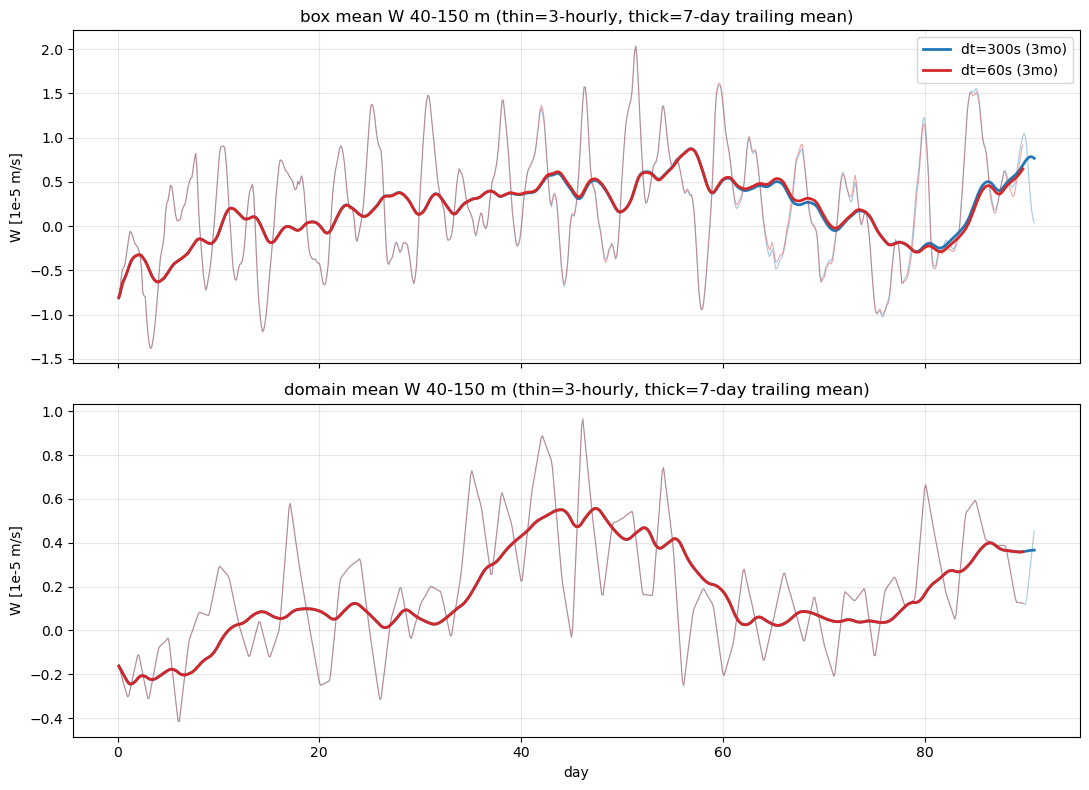

In [3]:
SPD = 8  # outputs per day

def running_mean(x):
    x = np.asarray(x, float)
    return np.cumsum(x) / (np.arange(x.size) + 1)

def rolling_mean(x, win=7*SPD):
    # trailing boxcar mean; first win-1 points use an expanding mean
    x = np.asarray(x, float)
    c = np.concatenate([[0.0], np.cumsum(x)])
    full = (c[win:] - c[:-win]) / win
    front = np.cumsum(x[:win-1]) / np.arange(1, win)
    return np.concatenate([front, full])

# 40-150 m band mean of the area-weighted W profile
up_box = {r: band_mean(ts[r]['wprof_box']) for r in ts}
up_dom = {r: band_mean(ts[r]['wprof_dom']) for r in ts}

fig, ax = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
for r in ts:
    d = ts[r]['days']
    ax[0].plot(d, up_box[r]*1e5, color=COL[r], alpha=.4, lw=.8)
    ax[0].plot(d, rolling_mean(up_box[r])*1e5, color=COL[r], lw=2, label=LAB[r])
    ax[1].plot(d, up_dom[r]*1e5, color=COL[r], alpha=.4, lw=.8)
    ax[1].plot(d, rolling_mean(up_dom[r])*1e5, color=COL[r], lw=2)
ax[0].set(title='box mean W 40-150 m (thin=3-hourly, thick=7-day trailing mean)', ylabel='W [1e-5 m/s]')
ax[1].set(title='domain mean W 40-150 m (thin=3-hourly, thick=7-day trailing mean)', ylabel='W [1e-5 m/s]', xlabel='day')
ax[0].legend()
for a in ax:
    a.grid(alpha=.3)
plt.tight_layout(); show()

### Spin-up (approach-to-equilibrium) day

The forced solution evolves seasonally over Oct-Dec, so it does not reach a
constant value. `stab_day` therefore measures the spin-up transient only: the
first day the trailing 7-day mean enters and stays within `tol` of the run's own
final-14-day mean (its late-record quasi-equilibrium). This flags when the
initial-condition adjustment has decayed, not a globally steady state.

In [4]:
def stab_day(days, series, tol=0.10, win_days=7):
    rm = rolling_mean(series, win_days * SPD)
    target = np.nanmean(series[-14*SPD:])
    scale = max(abs(target), 0.5 * np.nanstd(series))
    if scale == 0:
        return None
    stable_from = None
    for i in range(len(rm)):
        if abs(rm[i] - target) / scale > tol:
            stable_from = None
        elif stable_from is None:
            stable_from = float(days[i])
    return stable_from

def fmt(v):
    return f'day {v:.0f}' if v is not None else 'still evolving@end'

for r in ts:
    print(f'{LAB[r]:16s} box mean W (40-150 m) settles', fmt(stab_day(ts[r]['days'], up_box[r])))
    print(f'{"":16s} domain mean W (40-150 m) settles', fmt(stab_day(ts[r]['days'], up_dom[r])))

dt=300s (3mo)    box mean W (40-150 m) settles still evolving@end
                 domain mean W (40-150 m) settles still evolving@end
dt=60s (3mo)     box mean W (40-150 m) settles still evolving@end
                 domain mean W (40-150 m) settles still evolving@end


## Per-run: eta and depth-integrated transport (barotropic adjustment)

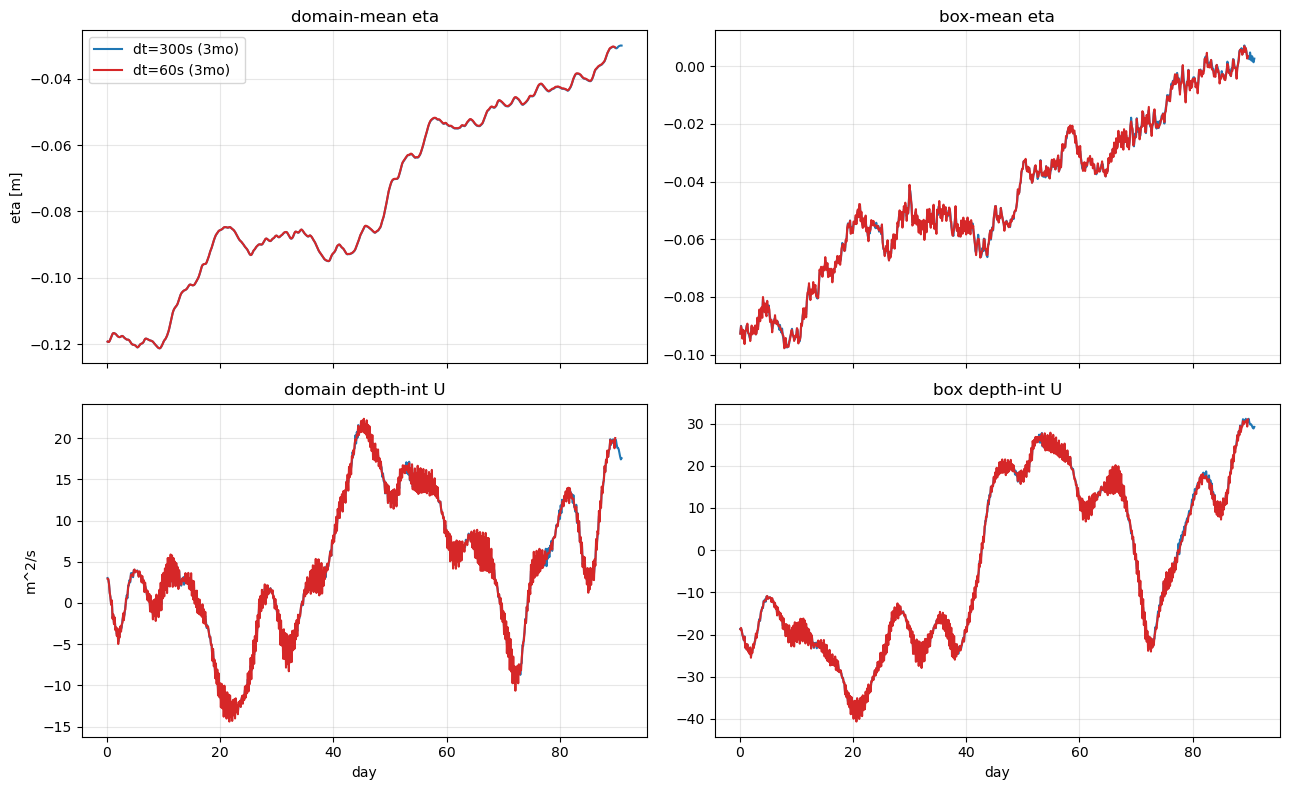

In [5]:
fig, ax = plt.subplots(2, 2, figsize=(13, 8), sharex='col')
for r in ts:
    d = ts[r]['days']
    ax[0, 0].plot(d, ts[r]['eta_dom'], color=COL[r], label=LAB[r])
    ax[0, 1].plot(d, ts[r]['eta_box'], color=COL[r])
    ax[1, 0].plot(d, ts[r]['utrans_dom'], color=COL[r])
    ax[1, 1].plot(d, ts[r]['utrans_box'], color=COL[r])
ax[0, 0].set(title='domain-mean eta', ylabel='eta [m]')
ax[0, 1].set(title='box-mean eta')
ax[1, 0].set(title='domain depth-int U', ylabel='m^2/s', xlabel='day')
ax[1, 1].set(title='box depth-int U', xlabel='day')
ax[0, 0].legend()
for a in ax.flat:
    a.grid(alpha=.3)
plt.tight_layout(); show()

## Per-run: CFL_w and vertical-velocity extremes

dt=300 shows both the model STDOUT monitor (advcfl_wvel_max, advcfl_W_hf_max,
dynstat_wvel_max) and the velocity-derived CFL_w. dt=60 shows velocity-derived
only. The overlap validates the velocity-derived estimate.

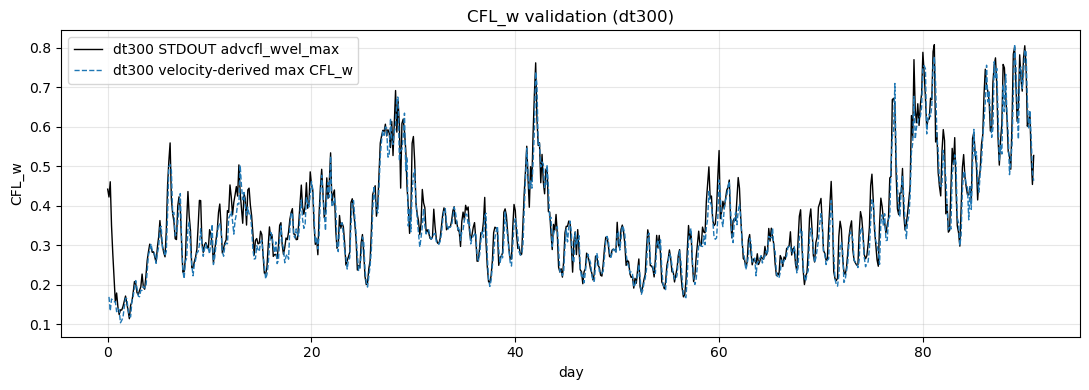

In [6]:
# validate velocity-derived CFL_w against dt300 STDOUT
fig, ax = plt.subplots(1, 1, figsize=(11, 4))
ax.plot(stdout['days'], stdout['advcfl_wvel_max'], color='k', lw=1,
        label='dt300 STDOUT advcfl_wvel_max')
ax.plot(ts['dt300']['days'], ts['dt300']['cflw_dom_max'], color='tab:blue', lw=1,
        ls='--', label='dt300 velocity-derived max CFL_w')
ax.set(title='CFL_w validation (dt300)', xlabel='day', ylabel='CFL_w'); ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); show()

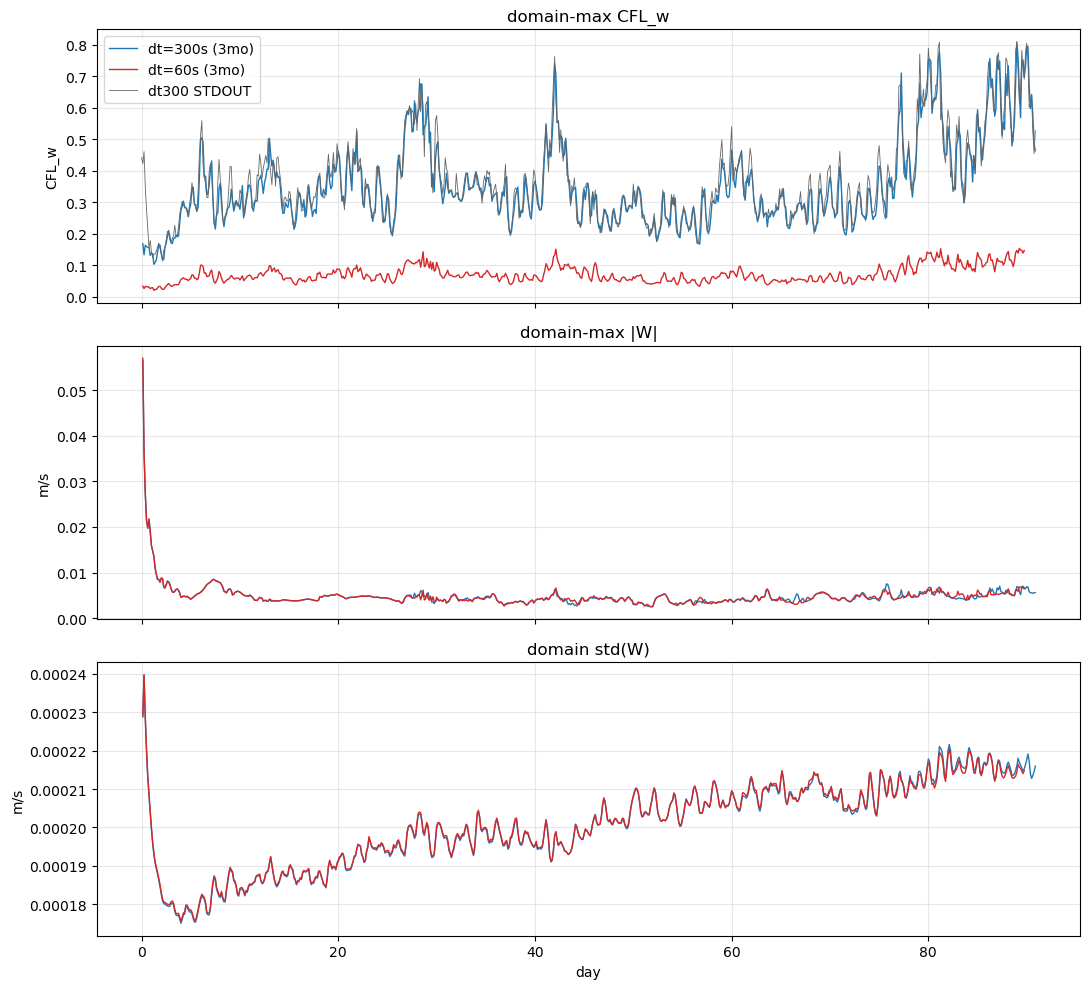

In [7]:
fig, ax = plt.subplots(3, 1, figsize=(11, 10), sharex=True)
for r in ts:
    d = ts[r]['days']
    ax[0].plot(d, ts[r]['cflw_dom_max'], color=COL[r], lw=1, label=LAB[r])
    ax[1].plot(d, ts[r]['wabs_dom_max'], color=COL[r], lw=1)
    ax[2].plot(d, ts[r]['wstd_dom'], color=COL[r], lw=1)
ax[0].plot(stdout['days'], stdout['advcfl_wvel_max'], color='0.4', lw=.6, label='dt300 STDOUT')
ax[0].set(title='domain-max CFL_w', ylabel='CFL_w'); ax[0].legend()
ax[1].set(title='domain-max |W|', ylabel='m/s')
ax[2].set(title='domain std(W)', ylabel='m/s', xlabel='day')
for a in ax:
    a.grid(alpha=.3)
plt.tight_layout(); show()

## Per-run: spatial maps of CFL_w (time-mean and time-max)

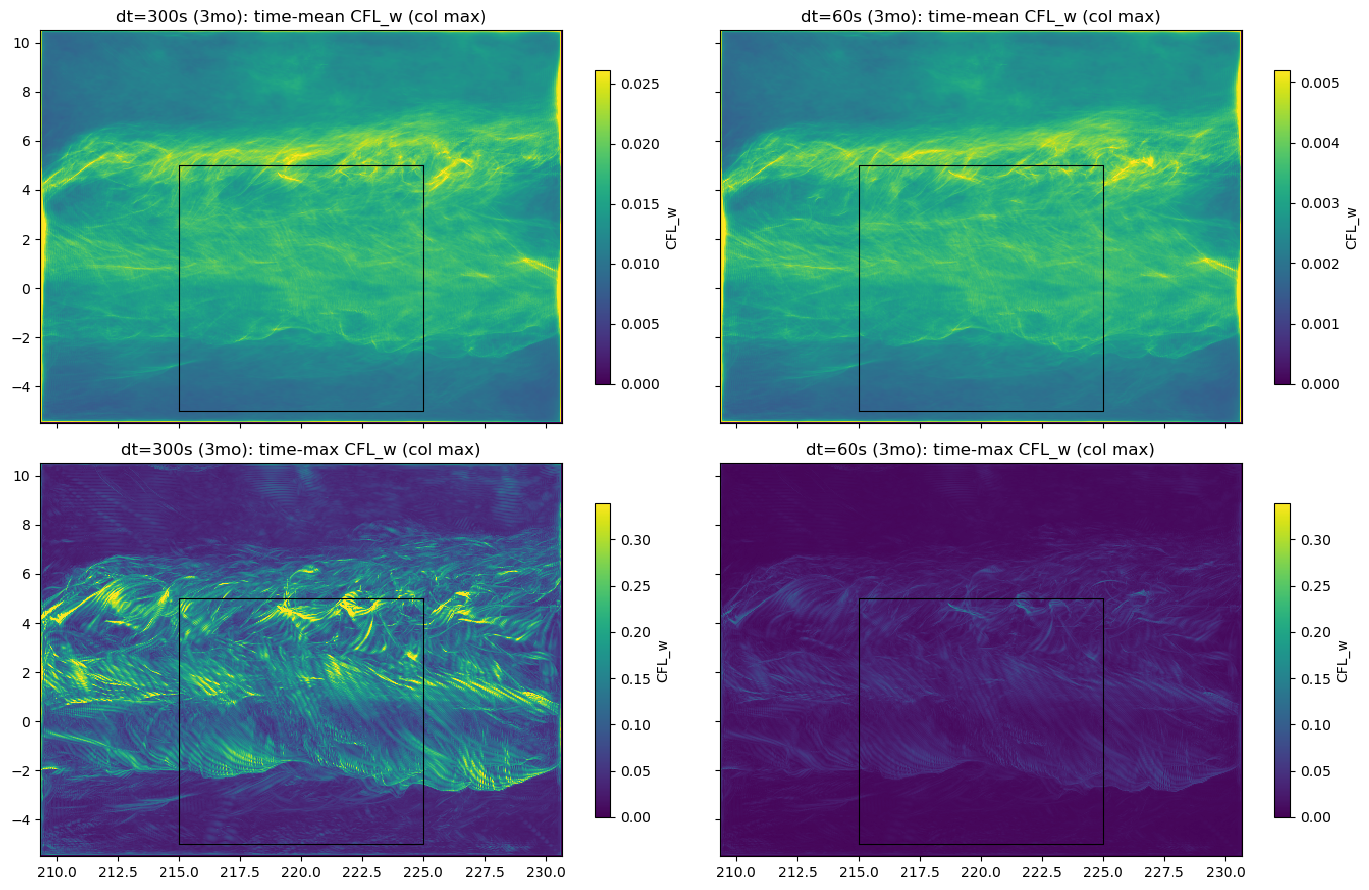

In [8]:
def pcm(ax, fld, title, vmax=None, cmap='viridis', center=False, label=''):
    # black square = 0N,140W +/-5deg analysis box (lon 215-225E, lat -5..5)
    if center:
        v = np.nanpercentile(np.abs(fld), 99)
        im = ax.pcolormesh(xc1d, yc1d, fld, cmap='RdBu_r', vmin=-v, vmax=v, shading='auto')
    else:
        vmax = vmax or np.nanpercentile(fld, 99.5)
        im = ax.pcolormesh(xc1d, yc1d, fld, cmap=cmap, vmin=0, vmax=vmax, shading='auto')
    ax.plot([215, 225, 225, 215, 215], [-5, -5, 5, 5, -5], 'k-', lw=.8)
    ax.set_title(title); plt.colorbar(im, ax=ax, shrink=.8, label=label)

vmax = max(np.nanpercentile(ts['dt300']['cfl_colmax_max'], 99.5),
           np.nanpercentile(ts['dt60']['cfl_colmax_max'], 99.5))
fig, ax = plt.subplots(2, 2, figsize=(14, 9), sharex=True, sharey=True)
for j, r in enumerate(('dt300', 'dt60')):
    pcm(ax[0, j], ts[r]['cfl_colmax_mean'], f'{LAB[r]}: time-mean CFL_w (col max)', label='CFL_w')
    pcm(ax[1, j], ts[r]['cfl_colmax_max'], f'{LAB[r]}: time-max CFL_w (col max)', vmax=vmax, label='CFL_w')
plt.tight_layout(); show()

## Per-run: time-mean near-surface W (full run vs equilibrated window)

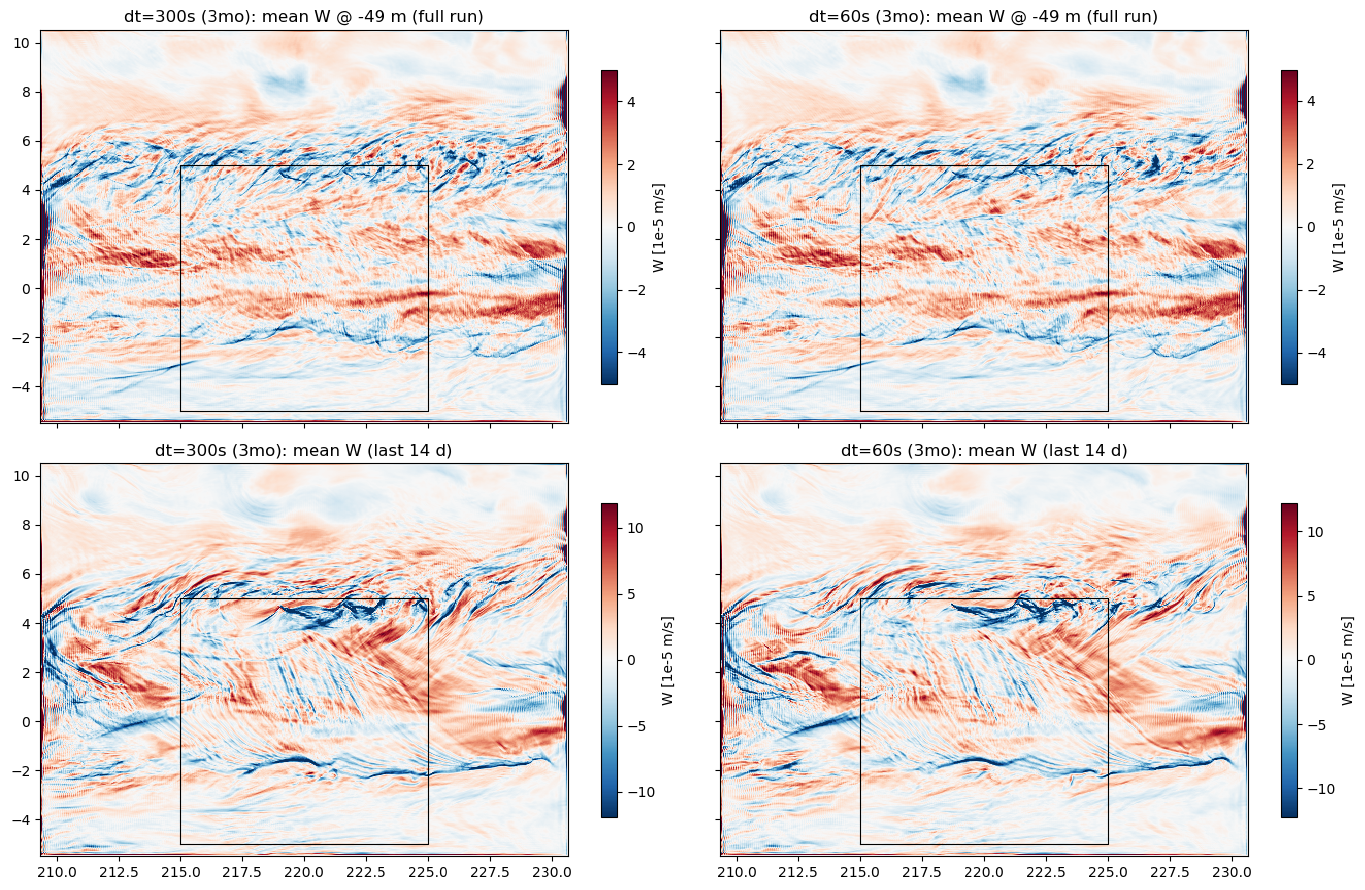

In [9]:
kd = int(ts['dt300']['ksurf'])
fig, ax = plt.subplots(2, 2, figsize=(14, 9), sharex=True, sharey=True)
for j, r in enumerate(('dt300', 'dt60')):
    pcm(ax[0, j], ts[r]['wsurf_full']*1e5, f'{LAB[r]}: mean W @ {depth[kd]:.0f} m (full run)', center=True, label='W [1e-5 m/s]')
    pcm(ax[1, j], ts[r]['wsurf_w14']*1e5, f'{LAB[r]}: mean W (last 14 d)', center=True, label='W [1e-5 m/s]')
plt.tight_layout(); show()

## Cross-run: mean W (40-150 m) on the matched full time axis

Both runs span ~90 days, so the full dt=60 and dt=300 series are overlaid directly
on the elapsed-day axis. Resemblance is the RMS difference of their running-mean
trajectories over the common record length.

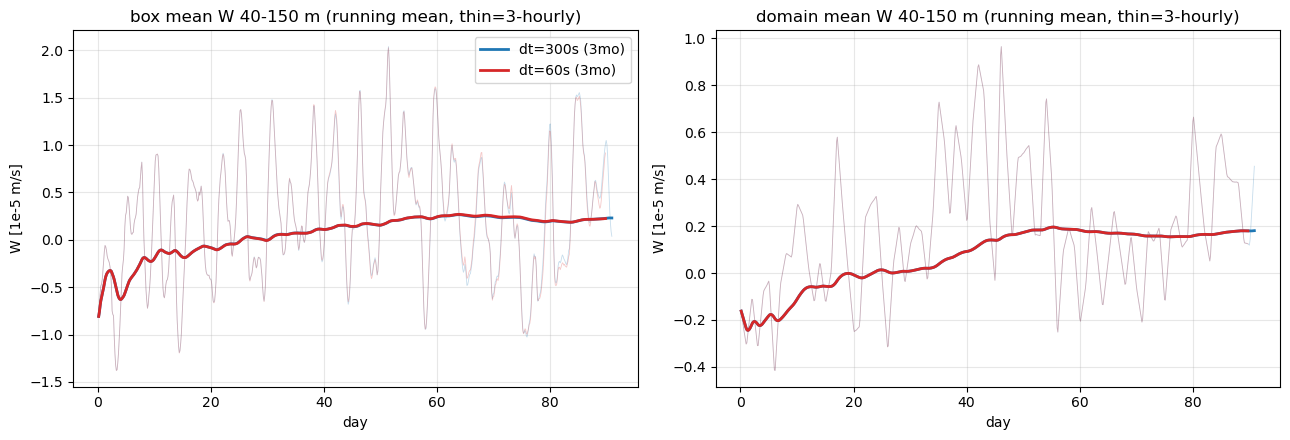

box: RMS(dt60 - dt300 running-mean over 90 d) = 2.77e-08 [m/s]
domain: RMS(dt60 - dt300 running-mean over 90 d) = 3.26e-10 [m/s]


In [10]:
n = min(ts['dt60']['days'].size, ts['dt300']['days'].size)  # common length

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
for k, (series, name) in enumerate([(up_box, 'box'), (up_dom, 'domain')]):
    for r in ts:
        ax[k].plot(ts[r]['days'], series[r]*1e5, color=COL[r], alpha=.25, lw=.6)
        ax[k].plot(ts[r]['days'], running_mean(series[r])*1e5, color=COL[r], lw=2, label=LAB[r])
    ax[k].set(title=f'{name} mean W 40-150 m (running mean, thin=3-hourly)', xlabel='day', ylabel='W [1e-5 m/s]')
    ax[k].grid(alpha=.3)
ax[0].legend()
plt.tight_layout(); show()

# resemblance: RMS difference of running-mean trajectories over the common length
for series, name in [(up_box, 'box'), (up_dom, 'domain')]:
    a = running_mean(series['dt60'])[:n]
    b = running_mean(series['dt300'])[:n]
    print(f'{name}: RMS(dt60 - dt300 running-mean over {n/8:.0f} d) = {np.sqrt(np.nanmean((a-b)**2)):.2e} [m/s]')

## Cross-run: running-mean convergence and stabilization day

In [11]:
print('spin-up settle day (trailing 7-d mean within 10% of run final 14-d mean):')
for series, name in [(up_box, 'box mean W'), (up_dom, 'domain mean W')]:
    for r in ts:
        print(f'  {name:18s} {LAB[r]:16s}', fmt(stab_day(ts[r]['days'], series[r])))

spin-up settle day (trailing 7-d mean within 10% of run final 14-d mean):
  box mean W         dt=300s (3mo)    still evolving@end
  box mean W         dt=60s (3mo)     still evolving@end
  domain mean W      dt=300s (3mo)    still evolving@end
  domain mean W      dt=60s (3mo)     still evolving@end


## Cross-run: difference of time-mean near-surface W maps

Two differences:
- dt60(first 30 d) - dt300(first 30 d): identical simulated time, isolates the
  timestep effect.
- dt60(90 d) - dt300(90 d): the full matched-length comparison.

A grid-scale roughness ratio (high-pass std / total std, 3x3 boxcar high-pass)
quantifies speckle (rectified noise) vs a smooth, coherent dynamical difference.

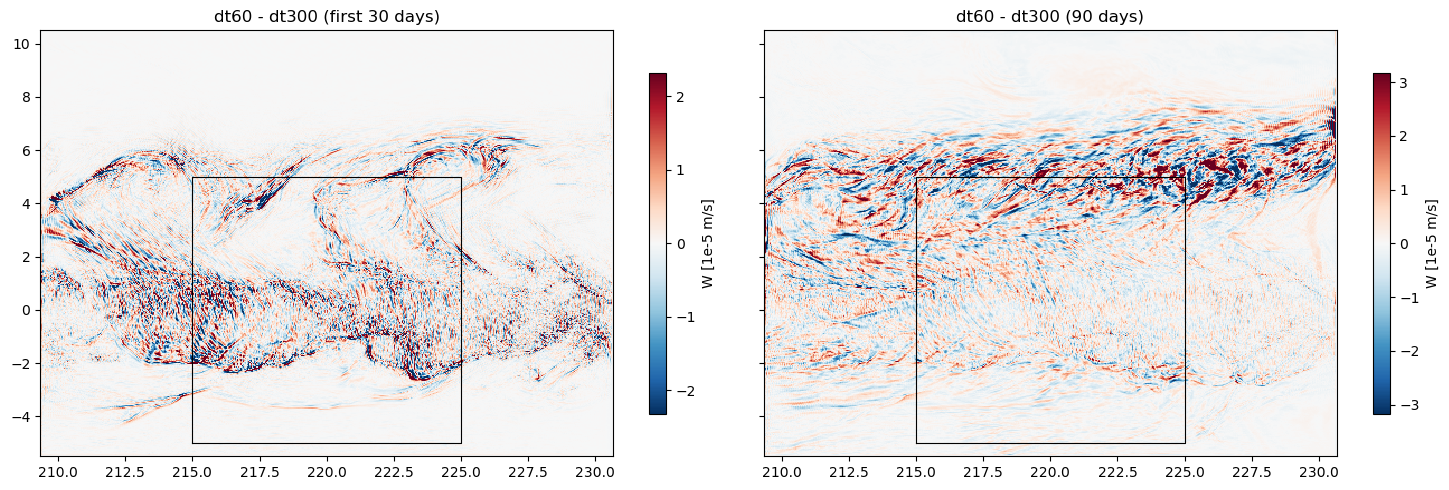

roughness ratio:
  first-30-day difference   : 0.766
  90-day difference         : 0.541
  dt=300s (3mo) 90-day mean W      : 0.795
  dt=60s (3mo) 90-day mean W      : 0.794
  RMS first-30-day diff [1e-5 m/s]: 0.561
  RMS 90-day diff [1e-5 m/s]: 0.806


In [12]:
from scipy.ndimage import uniform_filter

def roughness_ratio(f):
    hp = f - uniform_filter(f, size=3, mode='nearest')
    return float(np.nanstd(hp) / np.nanstd(f))

diff_same = wsw['dt60']['wsurf_first30'] - wsw['dt300']['wsurf_first30']
diff_full = wsw['dt60']['wsurf_full'] - wsw['dt300']['wsurf_full']

fig, ax = plt.subplots(1, 2, figsize=(15, 5), sharex=True, sharey=True)
pcm(ax[0], diff_same*1e5, 'dt60 - dt300 (first 30 days)', center=True, label='W [1e-5 m/s]')
pcm(ax[1], diff_full*1e5, 'dt60 - dt300 (90 days)', center=True, label='W [1e-5 m/s]')
plt.tight_layout(); show()

print('roughness ratio:')
print('  first-30-day difference   :', round(roughness_ratio(diff_same), 3))
print('  90-day difference         :', round(roughness_ratio(diff_full), 3))
for r in ts:
    print(f'  {LAB[r]} 90-day mean W      :', round(roughness_ratio(wsw[r]['wsurf_full']), 3))
print('  RMS first-30-day diff [1e-5 m/s]:', round(float(np.sqrt(np.nanmean(diff_same**2))*1e5), 3))
print('  RMS 90-day diff [1e-5 m/s]:', round(float(np.sqrt(np.nanmean(diff_full**2))*1e5), 3))

## Cross-run: CFL_w / W-variance trend on common time axis (first 30 days)

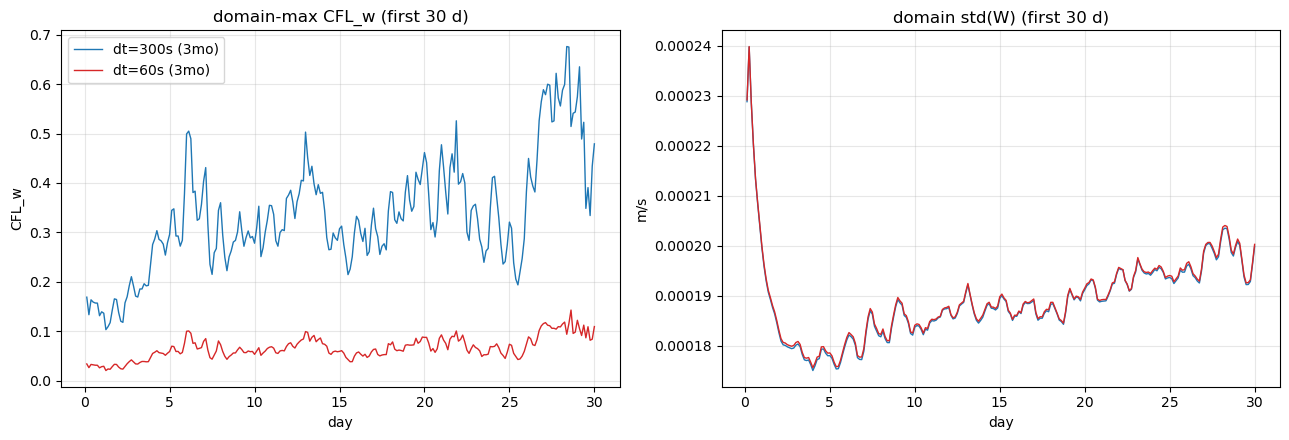

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
for r in ts:
    d = ts[r]['days']; m = d <= 30
    ax[0].plot(d[m], ts[r]['cflw_dom_max'][m], color=COL[r], lw=1, label=LAB[r])
    ax[1].plot(d[m], ts[r]['wstd_dom'][m], color=COL[r], lw=1)
ax[0].set(title='domain-max CFL_w (first 30 d)', xlabel='day', ylabel='CFL_w'); ax[0].legend()
ax[1].set(title='domain std(W) (first 30 d)', xlabel='day', ylabel='m/s')
for a in ax:
    a.grid(alpha=.3)
plt.tight_layout(); show()

## Summary table

For each run, the simulated day at which each indicator stabilizes (trailing
7-day running-mean change < 5%), or 'trending' if not stabilized by end of record.

In [14]:
ind = ['up_box', 'eta_box', 'utrans_box', 'cflw_dom_max', 'wstd_dom']
lbl = ['box mean W', 'box eta', 'box transp', 'CFL_w max', 'std(W)']
def series_for(r, key):
    return up_box[r] if key == 'up_box' else ts[r][key]

settled = {r: {k: stab_day(ts[r]['days'], series_for(r, k)) for k in ind} for r in ts}
print(f'{"run":16s} ' + ' '.join(f'{x:18s}' for x in lbl))
for r in ts:
    print(f'{LAB[r]:16s} ' + ' '.join(f'{fmt(settled[r][k]):18s}' for k in ind))

# mechanical rectified-noise flag: equilibrated box mean-W differs by > tol while
# every indicator has settled in both runs (else the difference is spin-up/seasonal)
up60 = np.nanmean(up_box['dt60'][-14*8:])
up300 = np.nanmean(up_box['dt300'][-14*8:])
rel = abs(up60 - up300) / abs(up300)
all_settled = all(settled[r][k] is not None for r in ts for k in ind)
print(f'\nlast-14-day box mean W (40-150 m): dt60={up60*1e5:.3f}  dt300={up300*1e5:.3f}'
      f' [1e-5 m/s]  rel diff={rel:.1%}')
print(f'first-30-day near-surface W map RMS diff = {np.sqrt(np.nanmean(diff_same**2))*1e5:.3f} [1e-5 m/s]')
print(f'90-day near-surface W map RMS diff       = {np.sqrt(np.nanmean(diff_full**2))*1e5:.3f} [1e-5 m/s]')
print(f'all indicators settled in both runs: {all_settled}')
print(f'rectified-noise flag (diff persists AND all settled): {all_settled and rel > 0.10}')

run              box mean W         box eta            box transp         CFL_w max          std(W)            
dt=300s (3mo)    still evolving@end still evolving@end still evolving@end day 82             day 27            
dt=60s (3mo)     still evolving@end still evolving@end still evolving@end day 82             day 26            

last-14-day box mean W (40-150 m): dt60=0.227  dt300=0.378 [1e-5 m/s]  rel diff=40.1%
first-30-day near-surface W map RMS diff = 0.561 [1e-5 m/s]
90-day near-surface W map RMS diff       = 0.806 [1e-5 m/s]
all indicators settled in both runs: False
rectified-noise flag (diff persists AND all settled): False


## Cross-run: depth-averaged horizontal velocity, same period (first 30 d)

W (vertical velocity) reflects only the divergent flow, which agrees same-period.
Depth-averaged U/V are dominated by the rotational flow. Here the same-period
(first 30 d) monthly-mean depth-averaged flow (0-70 m and 0-250 m) is compared
between runs, and separated from the temporal std of the depth-averaged velocity
over the month.

Diagnostics per band:
- vector pattern correlation of the monthly-mean flow between runs,
- RMS of the mean-flow difference vs RMS of the mean flow, and vs the RMS of the
  temporal std (mean-flow difference comparable to the temporal std indicates
  eddy-phase decorrelation rather than a systematically different mean circulation),
- large-scale vs grid-scale split of the difference (5x5 boxcar).

In [15]:
uv = {r: dict(np.load(f'{CACHE}/stab_uv30_{r}.npz')) for r in ('dt300', 'dt60')}
from scipy.ndimage import uniform_filter

def vcorr(u1, v1, u2, v2):
    num = np.nansum(u1*u2 + v1*v2)
    den = np.sqrt(np.nansum(u1**2 + v1**2) * np.nansum(u2**2 + v2**2))
    return num / den

def rms(*fields):
    return np.sqrt(np.nanmean(sum(f**2 for f in fields)))

print(f'{"band":8s} {"corr":>6s} {"RMS(mean)":>10s} {"RMS(diff)":>10s} '
      f'{"RMS(tstd)":>10s} {"diff/mean":>9s} {"diff/tstd":>9s}')
for b in ('70', '250'):
    u3, v3 = uv['dt300'][f'umean{b}'], uv['dt300'][f'vmean{b}']
    u6, v6 = uv['dt60'][f'umean{b}'], uv['dt60'][f'vmean{b}']
    du, dv = u6 - u3, v6 - v3
    rmean = 0.5*(rms(u3, v3) + rms(u6, v6))
    rdiff = rms(du, dv)
    reddy = 0.5*(rms(uv['dt300'][f'ustd{b}'], uv['dt300'][f'vstd{b}'])
                 + rms(uv['dt60'][f'ustd{b}'], uv['dt60'][f'vstd{b}']))
    print(f'0-{b:5s} {vcorr(u3,v3,u6,v6):6.3f} {rmean:10.4f} {rdiff:10.4f} '
          f'{reddy:10.4f} {rdiff/rmean:9.2f} {rdiff/reddy:9.2f}  [m/s]')

band       corr  RMS(mean)  RMS(diff)  RMS(tstd) diff/mean diff/tstd
0-70     1.000     0.3806     0.0014     0.2350      0.00      0.01  [m/s]
0-250    1.000     0.2202     0.0006     0.1309      0.00      0.00  [m/s]


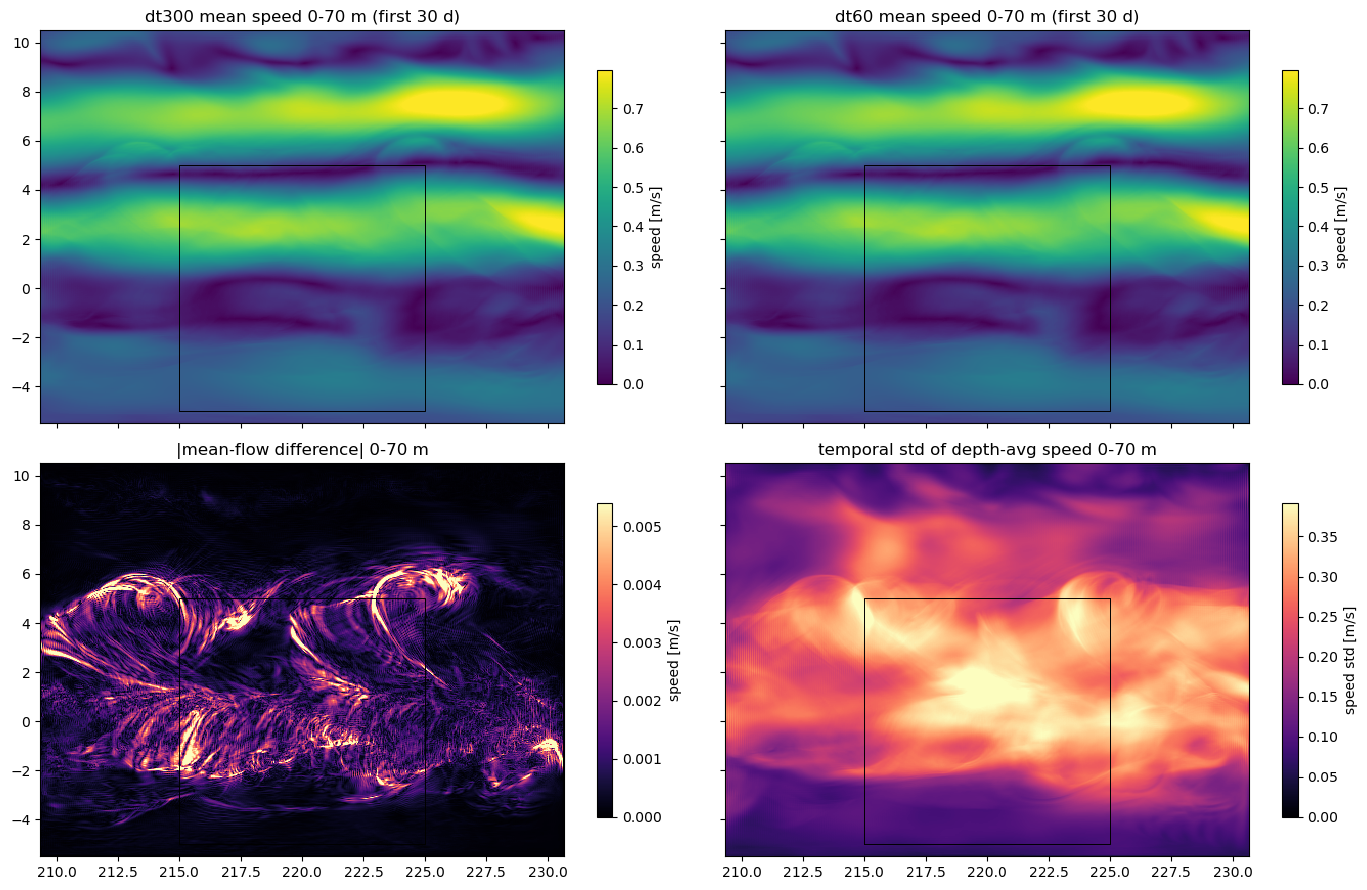

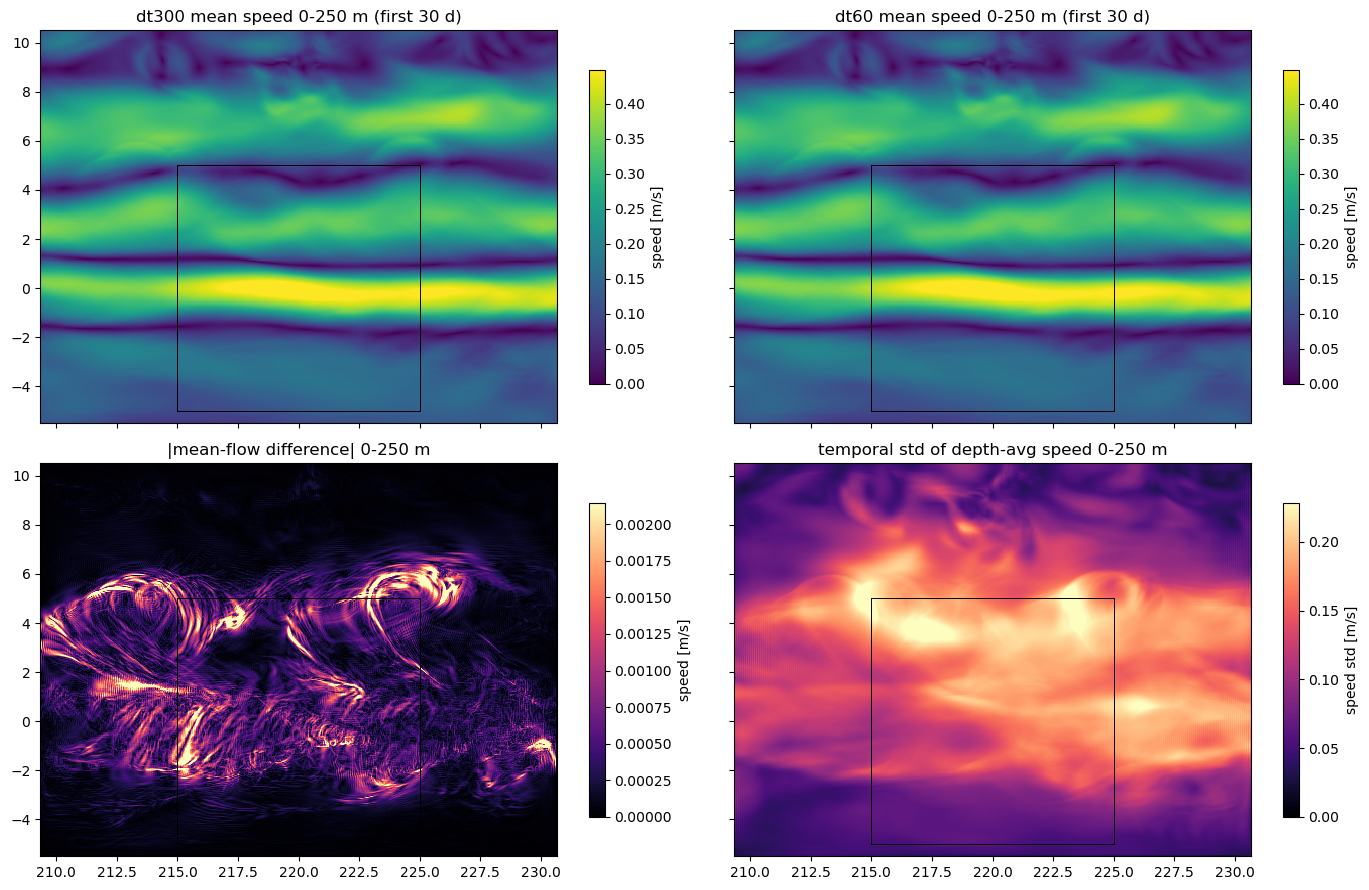

In [16]:
def spd(ax, u, v, title, vmax, cmap='viridis', label='speed [m/s]'):
    # black square = 0N,140W +/-5deg analysis box
    s = np.sqrt(u**2 + v**2)
    im = ax.pcolormesh(xc1d, yc1d, s, cmap=cmap, vmin=0, vmax=vmax, shading='auto')
    ax.plot([215, 225, 225, 215, 215], [-5, -5, 5, 5, -5], 'k-', lw=.7)
    ax.set_title(title); plt.colorbar(im, ax=ax, shrink=.8, label=label)

for b in ('70', '250'):
    u3, v3 = uv['dt300'][f'umean{b}'], uv['dt300'][f'vmean{b}']
    u6, v6 = uv['dt60'][f'umean{b}'], uv['dt60'][f'vmean{b}']
    vmax = np.nanpercentile(np.sqrt(u3**2+v3**2), 99)
    # the mean-flow difference is ~100x smaller than the flow itself, so scale it
    # to its own range (else it saturates to ~0 against the flow-speed vmax)
    dspd = np.sqrt((u6-u3)**2 + (v6-v3)**2)
    vmax_d = np.nanpercentile(dspd, 99)
    fig, ax = plt.subplots(2, 2, figsize=(14, 9), sharex=True, sharey=True)
    spd(ax[0, 0], u3, v3, f'dt300 mean speed 0-{b} m (first 30 d)', vmax)
    spd(ax[0, 1], u6, v6, f'dt60 mean speed 0-{b} m (first 30 d)', vmax)
    spd(ax[1, 0], u6-u3, v6-v3, f'|mean-flow difference| 0-{b} m', vmax_d, cmap='magma')
    reddy = 0.5*(np.sqrt(uv['dt300'][f'ustd{b}']**2+uv['dt300'][f'vstd{b}']**2)
                 + np.sqrt(uv['dt60'][f'ustd{b}']**2+uv['dt60'][f'vstd{b}']**2))
    im = ax[1, 1].pcolormesh(xc1d, yc1d, reddy, cmap='magma', vmin=0,
                             vmax=np.nanpercentile(reddy, 99), shading='auto')
    ax[1, 1].plot([215, 225, 225, 215, 215], [-5, -5, 5, 5, -5], 'k-', lw=.7)
    ax[1, 1].set_title(f'temporal std of depth-avg speed 0-{b} m')
    plt.colorbar(im, ax=ax[1, 1], shrink=.8, label='speed std [m/s]')
    plt.tight_layout(); show()

In [17]:
# split the mean-flow difference into large-scale (5x5 boxcar) and residual grid-scale
for b in ('70', '250'):
    du = uv['dt60'][f'umean{b}'] - uv['dt300'][f'umean{b}']
    dv = uv['dt60'][f'vmean{b}'] - uv['dt300'][f'vmean{b}']
    dul, dvl = uniform_filter(du, 5, mode='nearest'), uniform_filter(dv, 5, mode='nearest')
    large = rms(dul, dvl); total = rms(du, dv)
    print(f'0-{b} m difference: RMS total={total:.4f}  large-scale={large:.4f}  '
          f'large/total={large/total:.2f}  [m/s]')

0-70 m difference: RMS total=0.0014  large-scale=0.0010  large/total=0.74  [m/s]
0-250 m difference: RMS total=0.0006  large-scale=0.0004  large/total=0.77  [m/s]


## Reconciliation: source of the apparent large first-month difference

(Measured against the original 30-day dt=60 run; kept here as the reconciliation
of the earlier discrepancy. The delta_t caveat is independent of run length.)

The large first-month velocity difference seen in `tpose24-osse/demo_domain.ipynb`
traces to the model time axis, not the timestep. `osse_tools.load_model` defaults
`delta_t=300`; the dt60 run is loaded without overriding it, so its 30 days of
output are labelled as spanning Oct 1 - Feb 27 (150 days). Slicing
`time=slice('2012-10-08','2012-11-01')` then selects real simulated days ~1.5-6.4
(initial spin-up) for dt60, versus real days ~7-31 for dt300.

Measured (time/depth-mean U, 0-250 m; see verify_deltat_bug.py):
- RMS(dt60 with delta_t=60  - dt300) = 0.010 m/s  (~4% of field RMS 0.257)
- RMS(dt60 with delta_t=300 - dt300) = 0.121 m/s  (~47% of field RMS)

Fix: load the dt60 run with delta_t=60. With matched simulated time the two runs
agree to ~1% in W and depth-averaged U/V (this notebook), and dt300's
higher CFL_w is the definitional dt factor (CFL_w ratio = 5.02 = 300/60) on an
essentially identical W field.